In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from netCDF4 import Dataset
from regrid import regrid
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
import pickle
import itertools

# dir = '/home/robbie/uit_mnt/home/romal7177/algae'
# Made on the server
lpp,rpp = pickle.load(open(f'level_ridged_pens.p','rb'))#Level Partial Pen, Ridged Partial Pen
ltp = lpp*0.607
rtp = rpp*0.607

grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  ltp,
                  vmin = 0,
                  vmax = 0.25,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Penetration Factor',fontsize='x-large')
# plt.savefig('../figs/sit.png',dpi=500,bbox_inches='tight')

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  rtp,
                  vmin = 0,
                  vmax = 0.25,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Penetration Factor',fontsize='x-large')
# plt.savefig('../figs/sit.png',dpi=500,bbox_inches='tight')

# Made by process_ERA5.ipynb
ssrd = pickle.load(open('ssrd.p','rb'))/3600

mol = 0.79*4.44

ssrd_ridge_umol = np.multiply(mol*ssrd,rtp)
ssrd_level_umol = np.multiply(mol*ssrd,ltp)

pickle.dump((ssrd_ridge_umol,ssrd_level_umol),open('umols.p','wb'))

(0.0, 100.0)

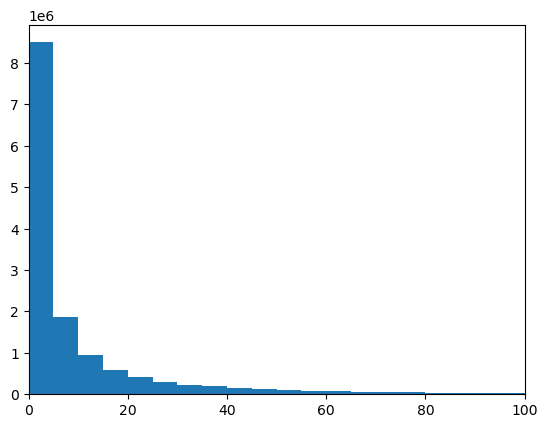

In [40]:
plt.hist(ssrd_ridged_umol.flatten(),bins=np.arange(0,200,5))
plt.xlim(0,100)